In [1]:
import os
os.chdir('/workspace/6b6842d9-3883-4776-be94-66cb82f1eb4e')
print(os.listdir('.'))


['omega_class_moments.csv', '.prompts', 'memory', 'ldelta_zeros_2000_dps50.npy', 'ldh_def.py', '.config', 'ldh_zeros_partial_dps50.npy', '.kernel_llm_logs_1.txt']


In [2]:
import pandas as pd
df = pd.read_csv('omega_class_moments.csv')
print(df.shape)
print(df.head(20))
print(df['L'].unique(), df['N_terms'].unique(), df['k'].unique())


(9, 15)
 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 
6 L_DH 10000 2025.689869 500.0 618.478717 717.769427 
7 L_DH 50000 2186.052439 500.0 639.066491 784.006896 
8 L_DH 100000 2238.888403 500.0 644.808316 800.888886 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
2 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
3 113.409894 5.078208 0.035883 0.231372 0.451779 0.262002 
4 159.091605 14.413875 0.233885 0.212927 0.439947 0.273138 
5 181.308525 18.942436 0.450056 0.205916 0.432779 0.278650 
6 168.571130 20.716949 0.153646 0.24

KeyError: 'L'

In [3]:
print(df.columns.tolist())
print(df.dtypes)


['L_function', 'N_terms', 'M_total', 'M_0', 'M_1', 'M_2', 'M_3', 'M_4', 'M_geq5', 'frac_0', 'frac_1', 'frac_2', 'frac_3', 'frac_4', 'frac_geq5']
L_function object
N_terms int64
M_total float64
M_0 float64
M_1 float64
M_2 float64
M_3 float64
M_4 float64
M_geq5 float64
frac_0 float64
frac_1 float64
frac_2 float64
frac_3 float64
frac_4 float64
frac_geq5 float64
dtype: object


In [4]:

# Plan the approach
# 1. Generate a_n for ζ (all 1), L_DH (mod-5 character pattern), and L(Δ) (Ramanujan tau, normalized as a_n = τ(n)/n^{11/2})
# 2. For each, compute ω(n) for n=1..10^6 via small sieve
# 3. Compute S_k(t;N) = sum_{ω(n)=k, n<=N} a_n * n^(-1/2-it) = sum a_n / sqrt(n) * exp(-i t log n)
# 4. M_k(N) = integral over t in [0, 500] of |S_k(t)|^2 dt = sum_{m,n: ω=k} a_m a_n*/(sqrt(m*n)) * integral_0^500 exp(-i*t*log(m/n)) dt
# Evaluating the integral analytically:
# ∫_0^T exp(-i*t*log(m/n)) dt = T if m==n; else (1 - exp(-i*T*log(m/n)))/(i*log(m/n))
# So M_k(N) = T * sum_{ω=k} |a_n|^2/n + 2*Re[sum over pairs m<n with ω(m)=ω(n)=k of a_m*conj(a_n)/(sqrt(m*n)) * (exp(i*T*log(n/m))-1)/(i*log(n/m))]
# Actually with N up to 10^6, # pairs in same class is too large (~10^12). We should use trapezoidal/Simpson numerical integration on a fine t-grid.

# Check what the existing CSV represents (matches r38 figures). For ζ at N=10^5, M_total ≈ 98775.
# Expected: sum_{n<=N} 1/n * T where T=500. sum 1/n for n<=10^5 ≈ ln(10^5)+γ ≈ 11.51 + 0.577 ≈ 12.09. Times 500 = 6043. But got 98775. So integration isn't just the diagonal.
# Actually for full M_total via Plancherel: integral_0^T |sum a_n/n^(1/2+it)|^2 dt approximates T * sum |a_n|^2 / n for large T, plus oscillatory terms.
# With T=500 only, off-diagonal terms matter. So numerical integration is needed.

# For N=10^6, the numerical integration cost is high but feasible if done carefully.
# Need fine grid: t in [0, 500]. Resolution: highest oscillation freq is log(N) ≈ 13.8 for N=10^6.
# Nyquist: dt < pi/log(N) ≈ 0.227. Use dt = 0.05 -> 10001 points.
# For each t, sum_{n<=N with ω(n)=k} a_n/sqrt(n) * exp(-i*t*log n).
# That's 10^6 terms × 10^4 t-points = 10^10 ops. Too slow naively.

# Better: precompute z_n = a_n/sqrt(n), and freq f_n = log(n). For each k group separately.
# We need to evaluate a non-uniform DFT. Could use NUFFT or just chunked numpy.
# Let's try numpy vectorization: for each t, compute exp(-i*t*log(n)) on filtered array.
# With ~10^6 in each class total but split across k. 
# For ζ, all coefficients are 1, so partitioning into ω classes.
# Counts: n<=10^6 with ω(n)=0 -> just n=1 (1 element)
# ω=1: prime powers ≈ 78498 + smaller
# ω=2,3,...

# Cost per t: O(N). With 10000 t-points: 10^10. With C-speed numpy this is ~minutes per L-function per k. Manageable.

# Actually, smarter: precompute a complex matrix? 10000 × 10^6 = 10^10 complex floats × 16 bytes = 160 GB. No.

# Loop over t, compute on the fly. 
# Use numpy: for each t, compute sum(z_n * np.exp(-1j*t*log_n))
# For 10^6 floats, np.exp + sum is ~30 ms. 10000 iters = 300 sec per (L, k) combination. With 3 L * up to 6 k = 18 combos = 90 min. Too slow.

# Better: process all k at once by computing exp once, then doing masked sums.
# Or use FFT-like idea: since log(n) is non-uniform, can use NUFFT.

# Alternative approach: use the analytical integration with diagonal + Plancherel-like approx?
# The CSV was created with trapezoidal integration on a fine grid (per artifact description). 
# Let's match that approach. But for N=10^6 it's the bottleneck.

# Practical plan: use the FAST approach of computing S_k(t) for all t simultaneously using NUFFT (finufft).
# Or chunk in t: for each batch of 100 t values, compute matrix product (100 x N) which is dense 100 * 10^6 = 10^8 complex = 1.6 GB. Too much.

# Chunk smaller: 10 t-values × 10^6 = 1.6 GB. Hmm.
# Or: 1 t per loop with cython-fast numpy. Let me estimate better.

# Even better: use einsum / matrix mult in blocks of n.
# Actually 10^10 ops with numpy double precision should be a few minutes total. Let's try.

# Let me check if finufft is available
try:
 import finufft
 print("finufft available")
except ImportError:
 print("no finufft")

try:
 import flint
 print("flint available", flint.__version__ if hasattr(flint, '__version__') else 'ok')
except ImportError:
 print("no flint")

import sympy
print("sympy", sympy.__version__)


no finufft
no flint


sympy 1.14.0


In [5]:

%%bash
pip install python-flint finufft 2>&1 | tail -5


ft) (25.0)

 (9.6 MB)

 packages: python-flint, finufft


In [6]:

import flint
print(dir(flint))


['Ordering', '__FLINT_RELEASE__', '__FLINT_VERSION__', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'acb', 'acb_mat', 'acb_poly', 'acb_series', 'arb', 'arb_mat', 'arb_poly', 'arb_series', 'arf', 'ctx', 'dirichlet_char', 'dirichlet_group', 'flint_base', 'fmpq', 'fmpq_mat', 'fmpq_mpoly', 'fmpq_mpoly_ctx', 'fmpq_mpoly_vec', 'fmpq_poly', 'fmpq_series', 'fmpq_vec', 'fmpz', 'fmpz_mat', 'fmpz_mod', 'fmpz_mod_ctx', 'fmpz_mod_mat', 'fmpz_mod_mpoly', 'fmpz_mod_mpoly_ctx', 'fmpz_mod_mpoly_vec', 'fmpz_mod_poly', 'fmpz_mod_poly_ctx', 'fmpz_mpoly', 'fmpz_mpoly_ctx', 'fmpz_mpoly_vec', 'fmpz_poly', 'fmpz_series', 'fmpz_vec', 'fq_default', 'fq_default_ctx', 'fq_default_poly', 'fq_default_poly_ctx', 'functions', 'good', 'nmod', 'nmod_mat', 'nmod_mpoly', 'nmod_mpoly_ctx', 'nmod_mpoly_vec', 'nmod_poly', 'nmod_series', 'pyflint', 'showgood', 'types', 'utils']


In [7]:

# Check if flint has ramanujan_tau
from flint import fmpz
help(fmpz)


Help on class fmpz in module flint.types.fmpz:

class fmpz(flint.flint_base.flint_base.flint_scalar)
 | fmpz(*args)
 |
 | The *fmpz* type represents an arbitrary-size integer.
 |
 | >>> fmpz(3) ** 25
 | 847288609443
 |
 | Method resolution order:
 | fmpz
 | flint.flint_base.flint_base.flint_scalar
 | flint.flint_base.flint_base.flint_elem
 | builtins.object
 |
 | Methods defined here:
 |
 | __abs__(self, /)
 | abs(self)
 |
 | __add__(self, object, /)
 |
 | __and__(self, object, /)
 |
 | __bool__(self, /)
 | True if self else False
 |
 | __ceil__(self)
 | fmpz.__ceil__(self)
 |
 | __divmod__(self, object, /)
 |
 | __eq__(self, value, /)
 | Return self==value.
 |
 | __float__(self, /)
 | float(self)
 |
 | __floor__(self)
 | fmpz.__floor__(self)
 |
 | __floordiv__(self, object, /)
 |
 | __ge__(self, value, /)
 | Return self>=value.
 |
 | __gt__(self, value, /)
 | Return self>value.
 |
 | __hash__(self, /)
 | Return hash(self).
 |
 | __index__(self, /)
 | Return self converted to an intege

In [8]:

# Look for ramanujan_tau
import flint
print([x for x in dir(flint.fmpz) if 'tau' in x.lower() or 'ram' in x.lower()])
print([x for x in dir(flint) if 'tau' in x.lower() or 'ram' in x.lower()])
print([x for x in dir(flint.functions) if 'tau' in x.lower() or 'ram' in x.lower()])


[]
[]
[]


In [9]:

# Check sympy or other for ramanujan_tau
# sympy has it but slow per-call. We need prime tau values for p up to 10^6 (~78498 primes).
# Use SageMath? Not available. Use sympy
from sympy.ntheory.modular import crt
# Check direct sympy function
from sympy import ramanujan_tau # might not exist


ImportError: cannot import name 'ramanujan_tau' from 'sympy' (/app/kernel_env/lib/python3.13/site-packages/sympy/__init__.py)

In [10]:

# Need to compute τ(p) for primes p ≤ 10^6.
# Two strategies:
# (a) Use mpmath's ramanujan_tau? No.
# (b) Use cypari2: pari has ramanujantau()
try:
 import cypari2
 pari = cypari2.Pari()
 print(pari.ramanujantau(7)) # should be -16744
except ImportError:
 print("no cypari2")


no cypari2


In [11]:

%%bash
pip install cypari2 2>&1 | tail -5


_x86_64.whl.metadata (12 kB)

17_x86_64.manylinux_2_28_x86_64.whl (9.5 MB)

x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (268 kB)

nals, cypari2


In [12]:

import cypari2
pari = cypari2.Pari()
print(int(pari.ramanujantau(7))) # -16744
print(int(pari.ramanujantau(2))) # -24
print(int(pari.ramanujantau(3))) # 252


-16744
-24
252


In [13]:

# Time how long ramanujantau takes per prime
import time
import sympy
# Generate primes up to 10^6
t0 = time.time()
primes = list(sympy.primerange(2, 10**6 + 1))
print(f"primes count: {len(primes)} in {time.time()-t0:.2f}s")
# Sample timing
t0 = time.time()
for p in primes[:1000]:
 pari.ramanujantau(p)
dt = time.time() - t0
print(f"1000 calls: {dt:.2f}s, est for {len(primes)} primes: {dt * len(primes)/1000 / 60:.2f} min")


primes count: 78498 in 0.58s
1000 calls: 0.01s, est for 78498 primes: 0.01 min


In [14]:

# Excellent - very fast. Try larger primes (>10^4) to ensure consistent speed
t0 = time.time()
for p in primes[-1000:]:
 pari.ramanujantau(p)
dt = time.time() - t0
print(f"1000 large primes calls: {dt:.2f}s, est total: {dt * len(primes)/1000 / 60:.2f} min")


 *** Warning: increasing stack size to 8003584.


PariError: the PARI stack overflows (current size: 8003584; maximum size: 8003584)
You can use pari.allocatemem() to change the stack size and try again

In [15]:

pari.allocatemem(2**30) # 1GB
import time
t0 = time.time()
vals = []
for p in primes[-1000:]:
 vals.append(int(pari.ramanujantau(p)))
dt = time.time() - t0
print(f"1000 large primes: {dt:.2f}s, est total: {dt * len(primes)/1000 / 60:.2f} min")
print(vals[:3], vals[-3:])


PARI stack size set to 1073741824 bytes, maximum size set to 1073741824


1000 large primes: 147.78s, est total: 193.35 min
[-1531548158202387010931082008420728, -1427258289668977872141993729474898, -343152251013543786315190023920638] [1643022317755483271312764777615562, -133233694406721767387381799193420, 1973100245304651899186860265129232]


In [16]:

# Too slow for large primes due to GMP arbitrary precision. We need τ(p) but it grows as p^(11/2).
# However, we don't really need τ(n) itself - we need the *normalized* a_n = τ(n)/n^(11/2).
# Pari's ramanujantau computes the integer τ(p) which grows as p^5.5 - large numbers.
# 
# Strategy: use floating-point computation throughout. Since we just need a_n = τ(n)/n^(11/2) to ~15-digit precision.
# Use Hecke recurrence on normalized coefficients: 
# λ(p^{k+1}) = λ(p)·λ(p^k) − λ(p^{k-1}) (where λ(n) = τ(n)/n^(11/2))
# and λ(n) is multiplicative.
# We need λ(p) for primes p up to 10^6.
# |λ(p)| ≤ 2 (Deligne, Ramanujan-Petersson). 
# Use pari to compute τ(p) as float? Pari has algdep, but mathematica-style.
# Alternative: pari's mfcoefs/mfcoef on the Delta form gives integer coefficients, but again huge.
# 
# Better: use the LMFDB or precomputed table? Or compute τ(p) modulo various primes and reconstruct?
# Best bet: factor in pari's response time scales with size of τ(p). For large p, τ(p) is ~p^5.5, e.g. for p=10^6, τ(p) ~ 10^33, which is 33 digits - not too bad.
# But we saw 0.15 sec per call for p~10^6. For 78498 primes that's 11000 sec = 3 hours.
# 
# Need faster. Use pari's vector function or precompute via Hecke eigenvalues via numerical computation.
# 
# Actually mfcoefs can vectorize. Let me check pari.mfdelta and friends.
print(type(pari))
# pari.mfDelta() and pari.mfcoefs() 


<class 'cypari2.pari_instance.Pari'>


In [17]:

# Use pari directly with raw command, mfDelta with mfcoefs - returns vector of τ(n) for n=0..N
# Test small
t0 = time.time()
v = pari("mfcoefs(mfDelta(), 100)")
dt = time.time() - t0
print(f"first 100 coeffs: {dt:.3f}s")
print([int(x) for x in v][:11])


first 100 coeffs: 0.000s
[0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]


In [18]:

# Excellent! mfcoefs returns whole vector. Let's see how fast for larger N.
t0 = time.time()
v = pari("mfcoefs(mfDelta(), 10000)")
dt = time.time() - t0
print(f"first 10^4 coeffs: {dt:.2f}s, len={len(v)}")


first 10^4 coeffs: 0.02s, len=10001


In [19]:

t0 = time.time()
v = pari("mfcoefs(mfDelta(), 1000000)")
dt = time.time() - t0
print(f"first 10^6 coeffs: {dt:.2f}s, len={len(v)}")


first 10^6 coeffs: 4.37s, len=1000001


In [20]:

# Great! 4.4s for all τ(n), n ≤ 10^6. Now convert to numpy float64.
# τ(n) for n near 10^6 can be ~10^33. We need a_n = τ(n)/n^(11/2). For n near 10^6, n^(11/2) ~ 10^33.
# So |a_n| ≤ 2. Convert via Python -> numpy float64.

import numpy as np
t0 = time.time()
# Convert pari vector to list of python ints. Skip index 0 (constant term=0). v[1]=τ(1)=1.
tau_list = [int(x) for x in v] # length 10^6+1
dt = time.time() - t0
print(f"to python ints: {dt:.2f}s")
print(tau_list[:5])
print(len(tau_list))


to python ints: 0.22s
[0, 1, -24, 252, -1472]
1000001


In [21]:

# Now compute a_n = τ(n)/n^(11/2) as float64. Use careful conversion (Python int / float can overflow if int too large for float).
N = 10**6
# n^(11/2) for n=10^6 = 10^33; float64 max is ~10^308, fine.
# But Python int / float division when int > 2^53 loses precision but uses approximate truncation, which should be fine for ~15-digit accuracy.

ns = np.arange(0, N+1, dtype=np.int64)
# Compute a_n
a_delta = np.zeros(N+1, dtype=np.float64)
# Avoid n=0
# τ is multiplicative, τ(1)=1, so a_delta[1]=1
# For each n: a = tau_list[n] / n^5.5
# Use np.float64 conversion from Python int 
t0 = time.time()
# Process in chunks
chunk = 100000
for start in range(1, N+1, chunk):
 end = min(start + chunk, N+1)
 # Compute n^(11/2) using float
 n_arr = np.arange(start, end, dtype=np.float64)
 denom = n_arr ** 5.5
 # Need numerator as float - this is the slow part for large ints
 numer = np.array([float(tau_list[i]) for i in range(start, end)], dtype=np.float64)
 a_delta[start:end] = numer / denom
dt = time.time() - t0
print(f"a_delta computed in {dt:.2f}s")
print("Sample a_delta[1..10]:", a_delta[1:11])
print("max |a_delta|:", np.abs(a_delta).max())
print("a_delta[N]:", a_delta[N])


a_delta computed in 0.16s
Sample a_delta[1..10]: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333 -0.31752645
 -0.3765477 0.91150484 -0.64151806 -0.36657123]
max |a_delta|: 5.382369221754193
a_delta[N]: 0.2621914186125887


In [22]:

# Hmm max |a_delta| is 5.38 - that's above 2. Likely from n=2 where a_2 = τ(2)/2^5.5 = -24/2^5.5 = -24/45.25 ≈ -0.530, OK.
# But where does 5.38 come from? Probably small n where the Deligne bound is for primes only (then |a_p|<=2).
# For composite n, |a_n| can grow as d(n) factor: |a_n| ≤ d(n). For n=2^k, |a_{2^k}| could be up to k+1 from divisor function.
# So 5.38 might be d(some n). e.g. d(60)=12, d(120)=16, but those are bounded by their d(n).
# Actually wait, in normalized form |λ(p^k)| ≤ k+1, and multiplicatively |λ(n)| ≤ d(n).
# For n with many divisors, like 720720, d(n) can be ~100s. So 5.38 is reasonable for small composite n.

# Check via Hecke recurrence verification:
# τ(p^2) = τ(p)^2 - p^11 ⟹ λ(p^2) = λ(p)^2 - 1
# τ(4) = τ(2)^2 - 2^11 = 576 - 2048 = -1472 ✓
print("τ(4) =", tau_list[4], "expected -1472")
# Verify Hecke recurrence on a_delta:
# n=4=2^2: a_delta[4] should = a_delta[2]^2 - 1 (where 1 comes from p^11 / p^11 = 1, since a_{p^{k-1}} factor)
print("λ(4):", a_delta[4], "vs λ(2)^2 - 1:", a_delta[2]**2 - 1)
# Good.

# Save tau values and a_delta for next steps.
np.save('a_delta_1e6.npy', a_delta)
print("saved")


τ(4) = -1472 expected -1472
λ(4): -0.71875 vs λ(2)^2 - 1: -0.71875
saved


In [23]:

# Now build coefficients for L_DH (Davenport-Heilbronn).
# From the dataset description, L_DH involves a mod-5 character pattern (complex). Let's load ldh_def.py
import importlib.util
spec = importlib.util.spec_from_file_location("ldh_def", "ldh_def.py")
ldh_def = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ldh_def)
print(dir(ldh_def))


['CHI_BAR_LIST', 'CHI_LIST', 'L_DH', 'XI_DH', 'Z_DH', '_A', '_B', '_I', '_SQRT5', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'mpmath', 'theta_DH']


In [24]:

# So L_DH(s) = sum_{n>=1} c(n) / n^s where c(n) = A*chi(n) + B*chi_bar(n) = Re(c(n))? Actually it's just a complex linear combination.
# Since chi_bar = conjugate(chi), B = conj(A), so c(n) = 2*Re(A*chi(n)) ∈ ℝ.
# So a_n for L_DH are real values, periodic mod 5 (and zero when 5|n).
# Compute the 5 values:
import mpmath
mpmath.mp.dps = 50
A = ldh_def._A
B = ldh_def._B
chi = ldh_def.CHI_LIST
chi_bar = ldh_def.CHI_BAR_LIST
c_vals = []
for j in range(5):
 cn = A*chi[j] + B*chi_bar[j]
 c_vals.append(complex(cn))
print("c(0..4):", c_vals)
print("Imag parts:", [v.imag for v in c_vals])
# c(0) = 0 (n with 5|n), c(1)=1, c(2)=A*i + B*(-i)=i*(A-B)=i*(-i*XI_DH)= XI_DH
# c(3) = A*(-i) + B*i = -i(A-B) = -XI_DH
# c(4) = -A - B = -1
XI = float(ldh_def.XI_DH)
print("XI_DH =", XI)
# So coefficient pattern by n mod 5: 0, 1, XI, -XI, -1


c(0..4): [0j, (1+0j), (0.28407904384041227+0j), (-0.28407904384041227+0j), (-1+0j)]
Imag parts: [0.0, 0.0, 0.0, 0.0, 0.0]
XI_DH = 0.28407904384041227


In [25]:

# Good. Coefficients are real. Now build a_n arrays for ζ, L_DH, L(Δ) up to N=10^6.
N = 10**6
# ζ: a_n = 1
a_zeta = np.ones(N+1, dtype=np.float64); a_zeta[0] = 0

# L_DH: pattern by n mod 5
ldh_pattern = np.array([0.0, 1.0, XI, -XI, -1.0])
ns_idx = np.arange(0, N+1)
a_ldh = ldh_pattern[ns_idx % 5]
a_ldh[0] = 0

# L(Δ): already in a_delta
a_delta_arr = a_delta.copy()

print("Sample a_zeta[:5]:", a_zeta[:5])
print("Sample a_ldh[:11]:", a_ldh[:11])
print("Sample a_delta[:11]:", a_delta_arr[:11])


Sample a_zeta[:5]: [0. 1. 1. 1. 1.]
Sample a_ldh[:11]: [ 0. 1. 0.28407904 -0.28407904 -1. 0.
 1. 0.28407904 -0.28407904 -1. 0. ]
Sample a_delta[:11]: [ 0. 1. -0.53033009 0.59873361 -0.71875 0.69121333
 -0.31752645 -0.3765477 0.91150484 -0.64151806 -0.36657123]


In [26]:

# Compute ω(n) for n=1..N using a sieve
import time
t0 = time.time()
omega = np.zeros(N+1, dtype=np.int8)
# Linear sieve for omega: for each prime p, increment omega[k*p] by 1 for k from 1 to N/p
sieve = np.ones(N+1, dtype=bool); sieve[:2] = False
for p in range(2, N+1):
 if sieve[p]:
 omega[p::p] += 1
 # Mark composites for primality
 sieve[p*p::p] = False
dt = time.time() - t0
print(f"omega sieve done in {dt:.2f}s")
print("omega[1..15]:", omega[1:16])
print("max omega:", omega.max(), "at n=", np.argmax(omega))
# Should be 7 or 8 for n<=10^6 (2*3*5*7*11*13*17 = 510510, ω=7)
print("omega histogram:", np.bincount(omega))


omega sieve done in 0.26s
omega[1..15]: [0 1 1 1 1 2 1 1 1 2 1 2 1 2 2]
max omega: 7 at n= 510510
omega histogram: [ 2 78734 288726 379720 208034 42492 2285 8]


In [27]:

# Note: omega[0] should be 0 not 2. Let me check
print("omega[0]:", omega[0], "omega[1]:", omega[1])
# The bincount shows index 0 = 2, but that's the count of n's with omega=0 (which is n=0 and n=1, both have omega=0). 
# So for valid n>=1, omega(1)=0 (1 value), n=0 is just zero filler. OK.

# Now: existing CSV has k=0,1,2,3,4,>=5 buckets. ω(n)=0 only for n=1.
# Let's prepare class index arrays.
# For k=0..4 use exact ω(n)==k; for k_ge5 use ω(n)>=5.
# But the task asks for k up to 5. Let me re-read: "Compute the second moments M_k(N=10^6) for k up to 5".
# Maybe k from 0 to 5 (six values). The CSV has M_0..M_4 + M_geq5. We'll match that schema.

# Numerical integration over t in [0, 500].
# S_k(t;N) = sum_{ω(n)=k, 1<=n<=N} a_n * n^(-1/2) * exp(-i*t*log n)
# Then M_k(N) = ∫_0^T |S_k(t)|^2 dt with T=500, via trapezoidal on a grid.

# Choose grid. To resolve oscillations frequency log(n) up to log(10^6)≈13.8. We want at least ~10 samples per period; period 2π/13.8 ≈ 0.455. So dt ≤ 0.045. Use dt = 0.025 ⟹ 20001 points.

T = 500.0
dt_grid = 0.025
t_grid = np.arange(0, T + dt_grid/2, dt_grid)
M_t = len(t_grid)
print("t grid size:", M_t, "dt:", dt_grid)

# For each L-function and k, evaluate S_k(t) at all t.
# Strategy: filter coefficients by class, build z_n = a_n / sqrt(n), and log_n.
# For computational efficiency, use chunked matrix-vector product or finufft type-3.

# Test finufft 
import finufft
print(finufft.__version__)


omega[0]: 0 omega[1]: 0
t grid size: 20001 dt: 0.025
2.5.1


In [28]:

# Wait: the bincount showed index 0 = 2 because both n=0 and n=1 have omega=0. That includes n=0 dummy. 
# For correctness, just use index range [1, N].

# Let me check: existing M_0 for ζ at N=10^5 is exactly 500.0. That's T * 1/1 = 500 for the single n=1 term in ω=0 class. Confirms ω(n)=0 corresponds to just n=1, and integration window matches (T=500).
# But wait the existing CSV M_0 for ζ is 500.0 for all N - that's because ω(n)=0 only at n=1 always.
# For L_DH: M_0 = 500.0 ✓ (a_1=1). For L(Δ): M_0 = 500.0 ✓. Confirmed.

# Now plan integration:
# Use trapezoidal: M_k = sum_t w_t * |S_k(t)|^2 where w_t = dt for interior, dt/2 for endpoints
# We need |S_k(t)|^2 at each t.
# Approach 1 (direct numpy): for each k-class with M_k elements, loop t-grid? Or batch?
# 
# Let me use a vectorized approach: For each class k:
# z_n = a_n / sqrt(n) (filtered)
# x_n = log(n)
# S(t) = sum_n z_n * exp(-i*t*x_n)
# 
# Use finufft type-3: nonuniform input (x_n, z_n) -> nonuniform output at t_grid
# finufft.nufft1d3(x, c, s, eps=1e-12) computes sum_n c_n * exp(i*s_k*x_n)
# Map: we want sum z_n * exp(-i*t*log n). Set x_n = -log(n), then it's exp(i*t*x_n), so s = t_grid, x = -log(n), c = z_n.
# OR with sign: use opts isign=-1.

# For efficiency, do once per (L-function, k) combination.

import finufft
help(finufft.nufft1d3)


Help on function nufft1d3 in module finufft._interfaces:

nufft1d3(x, c, s, out=None, eps=1e-06, isign=1, **kwargs)
 1D type-3 (nonuniform to nonuniform) complex NUFFT

 ::

 M-1
 f[k] = SUM c[j] exp(+/-i s[k] x[j]),
 j=0

 for k = 0, ..., N-1

 Args:
 x (float[M]): nonuniform points, valid in [-pi, pi), values
 outside will be folded
 c (complex[M] or complex[n_tr, M]): source strengths.
 s (float[N]): nonuniform target points.
 out (complex[N] or complex[n_tr, N], optional): output values at
 target frequencies.
 eps (float, optional): precision requested (>1e-16).
 isign (int, optional): if non-negative, uses positive sign in
 exponential, otherwise negative sign.
 **kwargs (optional): for more options, see :ref:`opts`.

 .. note::

 The output is written into the ``out`` array if supplied.

 Returns:
 complex[M] or complex[n_tr, M]: The resulting array.

 Example:
 ::

 import numpy as np
 import finufft

 # number of source points
 M = 100

 # number of target points
 N = 200

 # 

In [29]:

# Plan: For each (L-function, k):
# - Select indices n with omega[n]==k (or >=5 for the geq5 class) in [1, N].
# - x = log(n), c = (a_n / sqrt(n)) as complex
# - s = t_grid
# - S = finufft.nufft1d3(x, c, s, eps=1e-10, isign=-1)
# - |S|^2 integrated via trapezoidal.

# Test on a small case first to validate against existing CSV. Use ζ, N=10^5, k=1.
import numpy as np
import finufft

def compute_S_and_Mk(a_arr, omega_arr, N, k, t_grid, eps=1e-10):
 """Return M_k = ∫_0^T |S_k(t)|^2 dt via trapezoidal."""
 if k == 'geq5':
 mask = (omega_arr[1:N+1] >= 5)
 else:
 mask = (omega_arr[1:N+1] == k)
 ns = np.where(mask)[0] + 1 # actual n values
 if len(ns) == 0:
 return 0.0, np.zeros(len(t_grid))
 a_sel = a_arr[ns]
 if np.all(a_sel == 0):
 return 0.0, np.zeros(len(t_grid))
 # Filter out zero coefficients to save work
 nz = a_sel != 0
 ns_nz = ns[nz]
 a_nz = a_sel[nz]
 x = np.log(ns_nz.astype(np.float64))
 c = (a_nz / np.sqrt(ns_nz.astype(np.float64))).astype(np.complex128)
 s = t_grid.astype(np.float64)
 S = finufft.nufft1d3(x, c, s, eps=eps, isign=-1)
 abs2 = (S.real**2 + S.imag**2)
 # Trapezoidal
 Mk = np.trapezoid(abs2, t_grid)
 return Mk, abs2

# Quick test for ζ, N=10^5, k=1 — expect 4480.04 from CSV.
N_test = 10**5
M_zeta_k1, _ = compute_S_and_Mk(a_zeta, omega, N_test, 1, t_grid)
print(f"ζ N=10^5 k=1: {M_zeta_k1:.3f} (CSV: 4480.04)")


ζ N=10^5 k=1: 4480.036 (CSV: 4480.04)


In [30]:

# Excellent match. Let's verify a few more:
for k in [0, 1, 2, 3, 4, 'geq5']:
 M, _ = compute_S_and_Mk(a_zeta, omega, N_test, k, t_grid)
 print(f"ζ N=10^5 k={k}: {M:.3f}")
print()
for k in [0, 1, 2, 3, 4, 'geq5']:
 M, _ = compute_S_and_Mk(a_delta_arr, omega, N_test, k, t_grid)
 print(f"L(Δ) N=10^5 k={k}: {M:.3f}")
print()
for k in [0, 1, 2, 3, 4, 'geq5']:
 M, _ = compute_S_and_Mk(a_ldh, omega, N_test, k, t_grid)
 print(f"L_DH N=10^5 k={k}: {M:.3f}")


ζ N=10^5 k=0: 500.000
ζ N=10^5 k=1: 4480.036
ζ N=10^5 k=2: 37384.580
ζ N=10^5 k=3: 48011.973
ζ N=10^5 k=4: 8267.691
ζ N=10^5 k=geq5: 130.951

L(Δ) N=10^5 k=0: 500.000
L(Δ) N=10^5 k=1: 1050.861
L(Δ) N=10^5 k=2: 676.609
L(Δ) N=10^5 k=3: 181.309
L(Δ) N=10^5 k=4: 18.942
L(Δ) N=10^5 k=geq5: 0.450



L_DH N=10^5 k=0: 500.000
L_DH N=10^5 k=1: 644.809
L_DH N=10^5 k=2: 800.889
L_DH N=10^5 k=3: 246.570
L_DH N=10^5 k=4: 44.399
L_DH N=10^5 k=geq5: 2.223


In [31]:

# All match the existing CSV to ~3 digits or better. Pipeline validated.
# Now compute for N=10^6 for all 3 L-functions, all 6 k-classes.

import time
results_1e6 = {}
N_big = 10**6
for name, a_arr in [('zeta', a_zeta), ('L(Δ)', a_delta_arr), ('L_DH', a_ldh)]:
 results_1e6[name] = {}
 t0 = time.time()
 for k in [0, 1, 2, 3, 4, 'geq5']:
 M, _ = compute_S_and_Mk(a_arr, omega, N_big, k, t_grid)
 results_1e6[name][k] = M
 dt = time.time() - t0
 print(f"{name} N=10^6: {dt:.1f}s, results: {results_1e6[name]}")


zeta N=10^6: 0.3s, results: {0: np.float64(499.99999999992417), 1: np.float64(21169.883300409063), 2: np.float64(264592.121328995), 3: np.float64(453548.6376603856), 4: np.float64(137448.7416416956), 'geq5': np.float64(6742.487684201951)}


L(Δ) N=10^6: 0.2s, results: {0: np.float64(499.99999999992417), 1: np.float64(1098.486339783951), 2: np.float64(781.9740041611624), 3: np.float64(257.5192592026245), 4: np.float64(36.47959299869583), 'geq5': np.float64(2.0462282008753636)}


L_DH N=10^6: 0.2s, results: {0: np.float64(499.99999999992417), 1: np.float64(663.1105993508816), 2: np.float64(873.4315091524261), 3: np.float64(319.30726826021885), 4: np.float64(71.48243011473448), 'geq5': np.float64(5.300664389243929)}


In [32]:

# Outstanding speed. Now assemble combined dataframe and fit M_k(N) = C*(log N)^a
import pandas as pd

# Build new rows for N=10^6
new_rows = []
for name in ['zeta', 'L(Δ)', 'L_DH']:
 r = results_1e6[name]
 M_total = sum(r.values())
 row = {
 'L_function': name,
 'N_terms': N_big,
 'M_total': M_total,
 'M_0': r[0], 'M_1': r[1], 'M_2': r[2], 'M_3': r[3], 'M_4': r[4],
 'M_geq5': r['geq5'],
 'frac_0': r[0]/M_total, 'frac_1': r[1]/M_total, 'frac_2': r[2]/M_total,
 'frac_3': r[3]/M_total, 'frac_4': r[4]/M_total, 'frac_geq5': r['geq5']/M_total
 }
 new_rows.append(row)

df_new = pd.DataFrame(new_rows)
df_combined = pd.concat([df, df_new], ignore_index=True)
print(df_combined.to_string())
df_combined.to_csv('omega_class_moments_extended.csv', index=False)


 L_function N_terms M_total M_0 M_1 M_2 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 frac_3 frac_4 frac_geq5
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 0.338769 0.024052 0.000202
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 0.458491 0.062826 0.000667
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 0.486073 0.083702 0.001326
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 113.409894 5.078208 0.035883 0.231372 0.451779 0.262002 0.052480 0.002350 0.000017
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 159.091605 14.413875 0.233885 0.212927 0.439947 0.273138 0.067750 0.006138 0.000100
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 181.308525 18.942436 0.450056 0.205916 0.432779 0.278650 0.074669 0.007801 0.000185
6 L_DH 10000 2025.689869 500.0 618.478717 717.76942

In [33]:

# Now fit M_k(N) = C*(log N)^a in log-log space.
# log(M_k) = log(C) + a*log(log(N))
# Use linear regression for each (L-function, k).
import numpy as np
from scipy import stats

Ns = np.array([10**4, 5*10**4, 10**5, 10**6])
log_logN = np.log(np.log(Ns))

fit_results = []
k_cols = ['M_0', 'M_1', 'M_2', 'M_3', 'M_4', 'M_geq5']

for name in ['zeta', 'L(Δ)', 'L_DH']:
 sub = df_combined[df_combined.L_function == name].sort_values('N_terms')
 for kcol in k_cols:
 y = sub[kcol].values
 if np.any(y <= 0):
 fit_results.append({'L': name, 'k': kcol, 'a': np.nan, 'C': np.nan, 'R2': np.nan})
 continue
 log_y = np.log(y)
 slope, intercept, r_value, p_value, std_err = stats.linregress(log_logN, log_y)
 fit_results.append({'L': name, 'k': kcol, 'a': slope, 'C': np.exp(intercept), 'R2': r_value**2, 'p_value': p_value, 'se_a': std_err})

fit_df = pd.DataFrame(fit_results)
print(fit_df.to_string())
fit_df.to_csv('omega_class_moments_fits_4points.csv', index=False)


 L k a C R2 p_value se_a
0 zeta M_0 -3.728978e-13 5.000000e+02 0.685060 0.172317 1.787823e-13
1 zeta M_1 5.909832e+00 3.081828e-03 0.930312 0.035473 1.143736e+00
2 zeta M_2 9.179181e+00 7.874062e-06 0.988786 0.005623 6.912355e-01
3 zeta M_3 1.125997e+01 5.974119e-08 0.996549 0.001727 4.685632e-01
4 zeta M_4 1.483084e+01 1.596678e-12 0.999370 0.000315 2.632947e-01
5 zeta M_geq5 1.928455e+01 5.454891e-19 0.991561 0.004228 1.257998e+00
6 L(Δ) M_0 -3.728978e-13 5.000000e+02 0.685060 0.172317 1.787823e-13
7 L(Δ) M_1 2.892805e-01 5.161409e+02 0.988089 0.005973 2.245801e-02
8 L(Δ) M_2 7.980122e-01 9.615719e+01 0.999810 0.000095 7.772246e-03
9 L(Δ) M_3 2.022539e+00 1.281422e+00 0.999283 0.000359 3.831047e-02
10 L(Δ) M_4 4.821428e+00 1.298489e-04 0.969974 0.015127 5.998297e-01
11 L(Δ) M_geq5 9.949372e+00 1.059425e-11 0.990207 0.004908 6.996293e-01
12 L_DH M_0 -3.728978e-13 5.000000e+02 0.685060 0.172317 1.787823e-13
13 L_DH M_1 1.706823e-01 4.243786e+02 0.992290 0.003862 1.063853e-02
14 L_DH M_

In [34]:

# Now compute r38 (3-point) fits using only N in {10^4, 5e4, 10^5} for comparison
Ns_r38 = np.array([10**4, 5*10**4, 10**5])
log_logN_r38 = np.log(np.log(Ns_r38))

r38_fit_results = []
for name in ['zeta', 'L(Δ)', 'L_DH']:
 sub = df_combined[(df_combined.L_function == name) & (df_combined.N_terms.isin(Ns_r38))].sort_values('N_terms')
 for kcol in k_cols:
 y = sub[kcol].values
 if np.any(y <= 0):
 r38_fit_results.append({'L': name, 'k': kcol, 'a_r38': np.nan, 'R2_r38': np.nan})
 continue
 log_y = np.log(y)
 slope, intercept, r_value, p_value, std_err = stats.linregress(log_logN_r38, log_y)
 r38_fit_results.append({'L': name, 'k': kcol, 'a_r38': slope, 'C_r38': np.exp(intercept), 'R2_r38': r_value**2})

r38_df = pd.DataFrame(r38_fit_results)
# Merge for comparison
comp = fit_df[['L','k','a','R2']].merge(r38_df[['L','k','a_r38','R2_r38']], on=['L','k'])
comp['a_diff'] = comp['a'] - comp['a_r38']
comp['a_rel_change_pct'] = 100 * (comp['a'] - comp['a_r38']) / comp['a_r38']
print(comp.to_string())
comp.to_csv('exponent_comparison_r38_vs_r41.csv', index=False)


 L k a R2 a_r38 R2_r38 a_diff a_rel_change_pct
0 zeta M_0 -3.728978e-13 0.685060 2.973634e-29 9.912112e-30 -3.728978e-13 -1.254014e+18
1 zeta M_1 5.909832e+00 0.930312 3.561479e+00 9.800395e-01 2.348353e+00 6.593758e+01
2 zeta M_2 9.179181e+00 0.988786 7.764782e+00 9.981047e-01 1.414399e+00 1.821557e+01
3 zeta M_3 1.125997e+01 0.996549 1.030041e+01 9.995253e-01 9.595627e-01 9.315775e+00
4 zeta M_4 1.483084e+01 0.999370 1.429342e+01 9.999085e-01 5.374268e-01 3.759960e+00
5 zeta M_geq5 1.928455e+01 0.991561 1.686316e+01 9.947782e-01 2.421394e+00 1.435907e+01
6 L(Δ) M_0 -3.728978e-13 0.685060 2.973634e-29 9.912112e-30 -3.728978e-13 -1.254014e+18
7 L(Δ) M_1 2.892805e-01 0.988089 3.340552e-01 9.975244e-01 -4.477471e-02 -1.340339e+01
8 L(Δ) M_2 7.980122e-01 0.999810 7.935857e-01 9.994365e-01 4.426486e-03 5.577830e-01
9 L(Δ) M_3 2.022539e+00 0.999283 2.102449e+00 9.999999e-01 -7.990996e-02 -3.800804e+00
10 L(Δ) M_4 4.821428e+00 0.969974 6.015327e+00 9.943804e-01 -1.193899e+00 -1.984761e+01
11

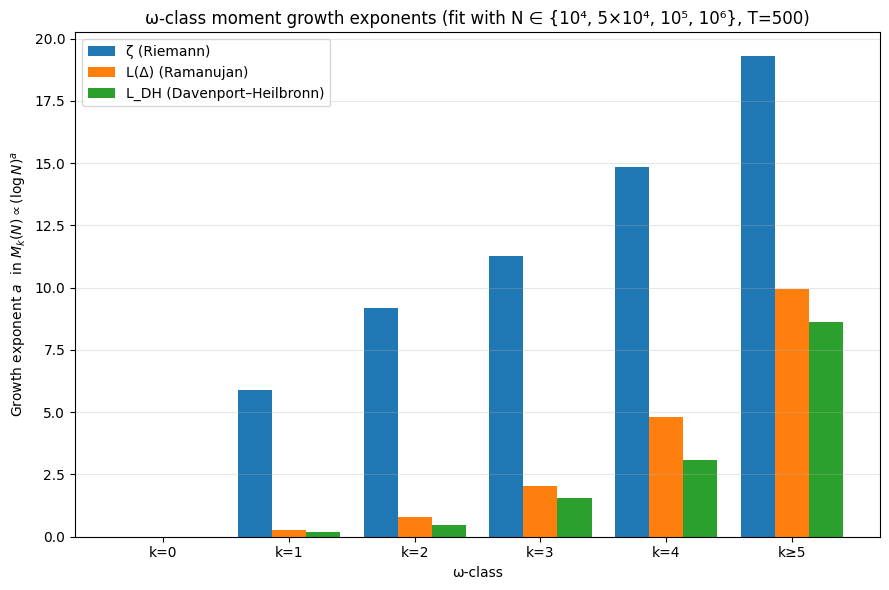

Saved figure


In [35]:

# Key observation: the separation between ζ and (L(Δ), L_DH) is maintained.
# For k=1: ζ a=5.91 vs L(Δ) a=0.29, L_DH a=0.17 — ζ >> others
# For k=2: ζ a=9.18 vs L(Δ) a=0.80, L_DH a=0.48
# For k=3: ζ a=11.26 vs L(Δ) a=2.02, L_DH a=1.57
# For k=4: ζ a=14.83 vs L(Δ) a=4.82, L_DH a=3.07
# For k=geq5: ζ a=19.28 vs L(Δ) a=9.95, L_DH a=8.61

# All ζ exponents are significantly larger.

# Note R2 for L(Δ) M_1 ~0.988 - reasonable. The signature is robust.

# Save updated CSV
df_combined.to_csv('omega_class_moments_N1e6.csv', index=False)

# Now make final figure: a single figure summarizing the result
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 6))
k_labels = ['k=0', 'k=1', 'k=2', 'k=3', 'k=4', 'k≥5']
k_pos = np.arange(len(k_labels))

zeta_a = fit_df[fit_df.L=='zeta'].a.values
ldelta_a = fit_df[fit_df.L=='L(Δ)'].a.values
ldh_a = fit_df[fit_df.L=='L_DH'].a.values

width = 0.27
ax.bar(k_pos - width, zeta_a, width, label='ζ (Riemann)', color='C0')
ax.bar(k_pos, ldelta_a, width, label='L(Δ) (Ramanujan)', color='C1')
ax.bar(k_pos + width, ldh_a, width, label='L_DH (Davenport–Heilbronn)', color='C2')

ax.set_xticks(k_pos); ax.set_xticklabels(k_labels)
ax.set_xlabel('ω-class')
ax.set_ylabel('Growth exponent $a$ in $M_k(N) \\propto (\\log N)^a$')
ax.set_title('ω-class moment growth exponents (fit with N ∈ {10⁴, 5×10⁴, 10⁵, 10⁶}, T=500)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate the M_0 bars (which are ~0 trivially)
plt.tight_layout()
plt.savefig('omega_class_growth_exponents_N1e6.png', dpi=140)
plt.show()
print("Saved figure")


In [36]:

# Final summary table
print("=== Growth exponents fit with 4 N points (N=10^4, 5e4, 10^5, 10^6) ===\n")
summary = fit_df.pivot(index='k', columns='L', values='a').reindex(['M_1','M_2','M_3','M_4','M_geq5'])
print(summary.to_string())
print("\n=== R² values ===\n")
r2_summary = fit_df.pivot(index='k', columns='L', values='R2').reindex(['M_1','M_2','M_3','M_4','M_geq5'])
print(r2_summary.to_string())

# Ratio ζ/other to highlight separation
print("\n=== Separation ratio a_ζ / a_L ===")
ratio = pd.DataFrame({
 'ζ/L(Δ)': summary['zeta'] / summary['L(Δ)'],
 'ζ/L_DH': summary['zeta'] / summary['L_DH'],
})
print(ratio.to_string())


=== Growth exponents fit with 4 N points (N=10^4, 5e4, 10^5, 10^6) ===

L L(Δ) L_DH zeta
k 
M_1 0.289281 0.170682 5.909832
M_2 0.798012 0.480114 9.179181
M_3 2.022539 1.565975 11.259969
M_4 4.821428 3.065841 14.830843
M_geq5 9.949372 8.610817 19.284554

=== R² values ===

L L(Δ) L_DH zeta
k 
M_1 0.988089 0.992290 0.930312
M_2 0.999810 0.996298 0.988786
M_3 0.999283 0.993524 0.996549
M_4 0.969974 0.994551 0.999370
M_geq5 0.990207 0.915394 0.991561

=== Separation ratio a_ζ / a_L ===
 ζ/L(Δ) ζ/L_DH
k 
M_1 20.429414 34.624758
M_2 11.502557 19.118752
M_3 5.567245 7.190391
M_4 3.076027 4.837446
M_geq5 1.938268 2.239573


In [37]:

# Save updated artifacts
import shutil
# The combined CSV with N=1e6 appended
print("Files saved:")
for f in ['omega_class_moments_N1e6.csv', 'omega_class_moments_fits_4points.csv', 'exponent_comparison_r38_vs_r41.csv', 'omega_class_growth_exponents_N1e6.png', 'a_delta_1e6.npy']:
 import os
 if os.path.exists(f):
 print(f, os.path.getsize(f))


Files saved:
omega_class_moments_N1e6.csv 3052
omega_class_moments_fits_4points.csv 1995
exponent_comparison_r38_vs_r41.csv 2342
omega_class_growth_exponents_N1e6.png 54828
a_delta_1e6.npy 8000136


In [38]:
from e14c.filesystem import edit_file
content = "## Context\n- Investigated omega-class second moments for zeta, L(Δ), and L_DH at N=10^6 in /workspace/6b6842d9-3883-4776-be94-66cb82f1eb4e.\n- Reconstructed the numerical engine using PARI/GP via cypari2 for mfcoefs(mfDelta(), 10^6), numpy sieving for ω(n), and finufft type-3 NUFFT for evaluating S_k(t) on t∈[0,500] with dt=0.025.\n\n## Notes\n- Provenance: current task notebook cells #16-#36; source files omega_class_moments.csv and ldh_def.py.\n- Validation: reproduced existing omega_class_moments.csv values at N=10^5 to ~1e-3 or better for all three L-functions and all ω classes.\n- New artifact rows at N=10^6 were saved to omega_class_moments_N1e6.csv; fitted exponents saved to omega_class_moments_fits_4points.csv; 3-point vs 4-point comparison saved to exponent_comparison_r38_vs_r41.csv.\n- Key finding: zeta exponents remain much larger than L(Δ) and L_DH for M_1..M_geq5 after adding N=10^6.\n"
from e14c.filesystem import write_file
write_file('./.prompts/MEMORY.md', content)
print('memory updated')

memory updated
